<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;
}
</style>

## **Faye**

<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Stock Price Prediction - Machine Learning Pipeline**

---

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
import json
import pandas as pd
import numpy as np
import warnings

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category = ConvergenceWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
msft = yf.Ticker("MSFT")
msft_hist = msft.history(period = "max")

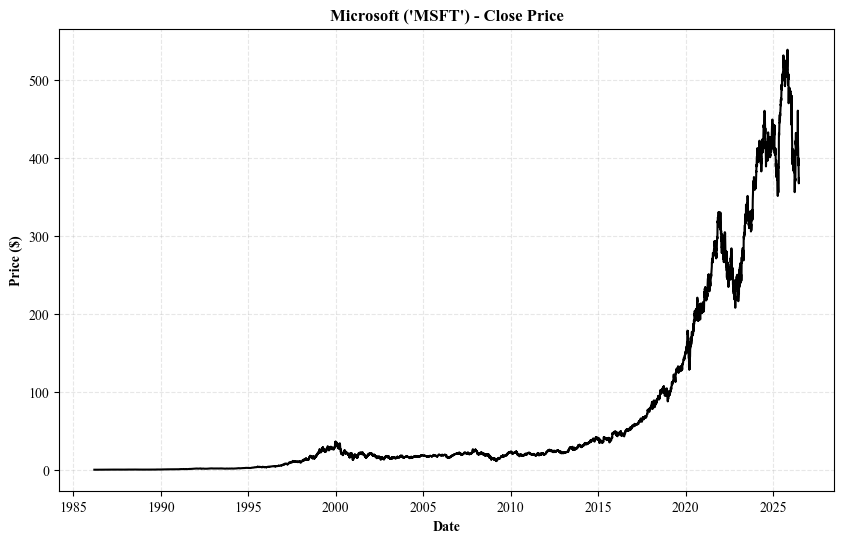

In [3]:
rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(msft_hist.index, msft_hist['Close'], color = 'black', linewidth = 1.5)
ax.set_title("Microsoft ('MSFT') - Close Price", fontweight = 'bold', fontsize = 12)
ax.set_xlabel("Date", fontweight = 'bold')
ax.set_ylabel("Price ($)", fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)
plt.show()

In [4]:
data = msft_hist[["Close"]]
data = data.rename(columns = {'Close': 'Actual Close'})
data["Target"] = msft_hist.rolling(2).apply(lambda x: x.iloc[1] > x.iloc[0])["Close"]

In [5]:
msft_prev = msft_hist.copy().shift(1)
predictors = ["Close", "High", "Low", "Open", "Volume"]
data = data.join(msft_prev[predictors]).iloc[1:]

In [6]:
weekly_mean = data.rolling(7).mean()
quarterly_mean = data.rolling(90).mean()
annual_mean = data.rolling(365).mean()
weekly_trend = data.shift(1).rolling(7).mean()["Target"]

In [7]:
data["weekly_mean"] = weekly_mean["Close"] / data["Close"]
data["quarterly_mean"] = quarterly_mean["Close"] / data["Close"]
data["annual_mean"] = annual_mean["Close"] / data["Close"]
data["annual_weekly_mean"] = data["annual_mean"] / data["weekly_mean"]
data["annual_quarterly_mean"] = data["annual_mean"] / data["quarterly_mean"]
data["weekly_trend"] = weekly_trend
data["open_close_ratio"] = data["Open"] / data["Close"]
data["high_close_ratio"] = data["High"] / data["Close"]
data["low_close_ratio"] = data["Low"] / data["Close"]

In [8]:
full_predictors = predictors + ["weekly_mean", 
                                "quarterly_mean", 
                                "annual_mean", 
                                "annual_weekly_mean", 
                                "annual_quarterly_mean", 
                                "open_close_ratio", 
                                "high_close_ratio", 
                                "low_close_ratio", 
                                "weekly_trend"]

In [9]:
def backtest(data, model, predictors, start = 1000, step = 750, threshold = 0.5):
    all_predictions = []
    
    for i in range(start, data.shape[0], step):
        train_data = data.iloc[: i].copy()
        test_data = data.iloc[i : i + step].copy()
        
        loop_scaler = StandardScaler()
        X_train_scaled = loop_scaler.fit_transform(train_data[predictors])
        X_test_scaled = loop_scaler.transform(test_data[predictors])
        
        model.fit(X_train_scaled, train_data["Target"])
        
        predictions = model.predict_proba(X_test_scaled)[:, 1]
        predictions = pd.Series(predictions, index = test_data.index)
        predictions[predictions > threshold] = 1
        predictions[predictions <= threshold] = 0
        
        combined_data = pd.concat({"Target": test_data["Target"], "Predictions": predictions}, axis = 1)
        all_predictions.append(combined_data)

    return pd.concat(all_predictions)

In [10]:
tuning_data = data.iloc[365:].dropna().copy()
tuning_scaler = StandardScaler()
X_tuning_scaled = tuning_scaler.fit_transform(tuning_data[full_predictors])
y_tuning = tuning_data["Target"].values

In [11]:
model_pipeline = {"Random Forest": {"model": RandomForestClassifier(random_state = 1),
                                    "threshold": 0.6,
                                    "grid": {'criterion': ['gini', 'entropy', 'log_loss'],
                                             'n_estimators': [50, 100, 200, 300], 
                                             'min_samples_split': [50, 100, 200, 300],
                                             'max_depth': [10, 20, 30, None], 
                                             'min_samples_leaf': [1, 2, 5, 10],
                                             'max_features': ['sqrt', 'log2', None]}
                                   },
                  "Logistic Regression": {"model": LogisticRegression(random_state = 1),
                                          "threshold": 0.5,
                                          "grid": {'penalty': ['l1', 'l2'],
                                                   'C': np.logspace(-4, 4, 10),
                                                   'solver': ['liblinear', 'saga'],
                                                   'max_iter': [3000, 5000],
                                                   'tol': [1e-3, 1e-2],
                                                   'fit_intercept': [True, False]}
                                         },
                  "Support Vector Machine": {"model": SVC(random_state = 1, probability = True),
                                             "threshold": 0.5,
                                             "grid": {'C': np.logspace(-2, 2, 5),
                                                      'kernel': ['linear', 'poly', 'rbf'],
                                                      'gamma': ['scale', 'auto', 0.1],
                                                      'degree': [2, 3],
                                                      'tol': [1e-3, 1e-2],
                                                      'shrinking': [True, False]}
                                            },
                  "K-Nearest Neighbours": {"model": KNeighborsClassifier(),
                                           "threshold": 0.5,
                                           "grid": {'n_neighbors': [5, 15, 30, 50],
                                                    'weights': ['uniform', 'distance'],
                                                    'metric': ['euclidean', 'manhattan'],
                                                    'algorithm': ['auto', 'ball_tree'],
                                                    'leaf_size': [30, 50],
                                                    'p': [1, 2]}
                                          },
                  "XGBoost": {"model": XGBClassifier(random_state = 1, eval_metric = 'logloss'),
                              "threshold": 0.6,
                              "grid": {'n_estimators': [50, 100, 200],
                                       'max_depth': [3, 6, 9],
                                       'learning_rate': [0.01, 0.05, 0.1],
                                       'subsample': [0.7, 1.0],
                                       'colsample_bytree': [0.7, 1.0],
                                       'min_child_weight': [1, 5, 10]}
                             },
                  "LightGBM": {"model": LGBMClassifier(random_state = 1, verbosity = -1),
                               "threshold": 0.6,
                               "grid": {'n_estimators': [50, 100, 200],
                                        'max_depth': [3, 6, -1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'num_leaves': [15, 31, 63],
                                        'min_child_samples': [10, 20, 30],
                                        'subsample': [0.7, 1.0]}
                              },
                  "CatBoost": {"model": CatBoostClassifier(random_state = 1, verbose = 0),
                               "threshold": 0.6,
                               "grid": {'iterations': [50, 100, 200],
                                        'depth': [4, 6, 8],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'l2_leaf_reg': [1, 5, 10],
                                        'border_count': [32, 64, 128],
                                        'random_strength': [0.0, 1.0]}
                              },
                  "Decision Tree": {"model": DecisionTreeClassifier(random_state = 1),
                                    "threshold": 0.6,
                                    "grid": {'criterion': ['gini', 'entropy', 'log_loss'],
                                             'max_depth': [5, 10, 20, None],
                                             'min_samples_split': [10, 50, 100],
                                             'min_samples_leaf': [5, 10, 20],
                                             'max_features': ['sqrt', 'log2', None],
                                             'ccp_alpha': [0.0, 0.001, 0.01]}
                                   },
                  "Linear Discriminant Analysis": {"model": LinearDiscriminantAnalysis(),
                                                   "threshold": 0.5,
                                                   "grid": {'solver': ['lsqr', 'eigen'],
                                                            'shrinkage': [None, 'auto', 0.1, 0.5],
                                                            'tol': [1e-4, 1e-3, 1e-2],
                                                            'store_covariance': [True, False],
                                                            'priors': [None, [0.5, 0.5]],
                                                            'n_components': [None, 1]}
                                                  }}

In [12]:
tscv = TimeSeriesSplit(n_splits = 5)
performance_leaderboard = {}
all_final_predictions = {}

for model_name, config in model_pipeline.items():
    
    print(f"--- Processing: {model_name} ---")

    random_search = RandomizedSearchCV(estimator = config["model"],
                                       param_distributions = config["grid"],
                                       n_iter = 10, 
                                       scoring = 'precision',
                                       cv = tscv,
                                       n_jobs = -1,
                                       random_state = 1)

    random_search.fit(X_tuning_scaled, y_tuning)
    optimised_model = random_search.best_estimator_
    print(f"Optimal parameters: {random_search.best_params_}")

    predictions = backtest(data = data.iloc[365:], 
                           model = optimised_model, 
                           predictors = full_predictors, 
                           threshold = config["threshold"])

    all_final_predictions[model_name] = predictions

    precision_score_3 = precision_score(predictions["Target"], predictions["Predictions"])
    performance_leaderboard[model_name] = precision_score_3

    print(f"Precision Score (precision_score_3): {precision_score_3:.4f}")

leaderboard_df = pd.DataFrame.from_dict(performance_leaderboard, 
                                        orient = 'index', 
                                        columns = ['Precision Score']).sort_values(by = 'Precision Score', 
                                                                                   ascending = False)
print(leaderboard_df)

--- Processing: Random Forest ---
Optimal parameters: {'n_estimators': 300, 'min_samples_split': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'gini'}
Precision Score (precision_score_3): 0.5859
--- Processing: Logistic Regression ---
Optimal parameters: {'tol': 0.01, 'solver': 'saga', 'penalty': 'l2', 'max_iter': 3000, 'fit_intercept': False, 'C': np.float64(166.81005372000558)}
Precision Score (precision_score_3): 0.5453
--- Processing: Support Vector Machine ---
Optimal parameters: {'tol': 0.01, 'shrinking': True, 'kernel': 'poly', 'gamma': 'scale', 'degree': 2, 'C': np.float64(0.01)}
Precision Score (precision_score_3): 0.5066
--- Processing: K-Nearest Neighbours ---
Optimal parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 30, 'metric': 'manhattan', 'leaf_size': 50, 'algorithm': 'auto'}
Precision Score (precision_score_3): 0.5202
--- Processing: XGBoost ---
Optimal parameters: {'subsample': 1.0, 'n_estimators': 50, 'min_child_weight': 10

C:\Users\dilan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision Score (precision_score_3): 0.0000
--- Processing: Decision Tree ---
Optimal parameters: {'min_samples_split': 100, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': None, 'criterion': 'log_loss', 'ccp_alpha': 0.0}
Precision Score (precision_score_3): 0.5081
--- Processing: Linear Discriminant Analysis ---
Optimal parameters: {'tol': 0.01, 'store_covariance': False, 'solver': 'eigen', 'shrinkage': None, 'priors': None, 'n_components': None}
Precision Score (precision_score_3): 0.5366
                              Precision Score
Random Forest                        0.585915
Logistic Regression                  0.545266
LightGBM                             0.542607
Linear Discriminant Analysis         0.536567
XGBoost                              0.531490
K-Nearest Neighbours                 0.520227
Decision Tree                        0.508065
Support Vector Machine               0.506623
CatBoost                             0.000000


In [15]:
best_model = leaderboard_df.index[0]
best_predictions_df = all_final_predictions[best_model]
best_model

'Random Forest'